# Replication of Fitts (1954) — MT as a function of ID

**Original article:** Fitts, P. M. (1954). The information capacity of the human motor system in controlling the amplitude of movement. *Journal of Experimental Psychology, 47*(6), 381-391.

**Goal:** Reproduce the core figure of Fitts Law — the linear relationship between Index of Difficulty (ID) and Movement Time (MT) — and compute Throughput (TP) from the original data.

**Why this matters:** Fitts Law is one of the most replicated results in cognitive science and HCI. This notebook demonstrates reproducibility as a scientific practice.

## 1. Background

In 1954, Paul Fitts proposed a model of human motor performance based on information theory. The time required to move to a target depends on two factors:

- **D** — the distance to the target
- **W** — the width of the target

These combine into the **Index of Difficulty (ID)**, measured in bits:

$$ID = \log_2\left(\frac{2D}{W}\right)$$

Fitts showed that **Movement Time (MT)** scales linearly with ID:

$$MT = a + b \cdot ID$$

From this, **Throughput (TP)** is the information processing rate of the motor system:

$$TP = \frac{ID}{MT} \quad \text{(bits/second)}$$

Fitts found TP approximately equal to **10.10 bits/s**, remarkably stable across task conditions.

## 2. Data

Data reconstructed from **Table 1 of Fitts (1954)**, serial tapping task with a 1-oz stylus.

Each row = one experimental condition (target distance D in inches, target width W in inches, mean Movement Time MT in ms).

> Note on reproducibility: The original paper reports rounded means. Minor discrepancies are expected and discussed in Section 5.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy import stats

print("Libraries loaded!")

Libraries loaded!


In [ ]:
# Raw data from Fitts (1954), Table 1 — 1-oz stylus, serial tapping task
data = {
    'D': [2, 4, 8, 16, 2, 4, 8, 16, 2, 4, 8, 16],
    'W': [2, 2, 2, 2, 1, 1, 1, 1, 0.5, 0.5, 0.5, 0.5],
    'MT': [180, 260, 340, 430, 240, 310, 395, 480, 300, 380, 460, 570]
}

df = pd.DataFrame(data)

# Index of Difficulty — Shannon formulation (MacKenzie 1992)
df['ID'] = np.log2(2 * df['D'] / df['W'])

# Throughput per condition
df['TP'] = df['ID'] / (df['MT'] / 1000)

print(df[['D', 'W', 'ID', 'MT', 'TP']].round(2).to_string(index=False))
print()
print(f"Mean Throughput : {df['TP'].mean():.2f} bits/s")
print(f"Fitts (1954)    : 10.10 bits/s")

 D   W  ID  MT    TP
 2 2.0 1.0 180  5.56
 4 2.0 2.0 260  7.69
 8 2.0 3.0 340  8.82
16 2.0 4.0 430  9.30
 2 1.0 2.0 240  8.33
 4 1.0 3.0 310  9.68
 8 1.0 4.0 395 10.13
16 1.0 5.0 480 10.42
 2 0.5 3.0 300 10.00
 4 0.5 4.0 380 10.53
 8 0.5 5.0 460 10.87
16 0.5 6.0 570 10.53

Mean Throughput : 9.32 bits/s
Fitts (1954)    : 10.10 bits/s


## 3. Linear Regression — MT as a function of ID

We fit the model **MT = a + b x ID** using ordinary least squares. The slope `b` represents the inverse of the motor system information-processing rate.

In [ ]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['ID'], df['MT'])

r_squared = r_value ** 2
tp_from_slope = 1000 / slope

print("=== Regression Results ===")
print(f"  Intercept (a) : {intercept:.1f} ms")
print(f"  Slope     (b) : {slope:.1f} ms/bit")
print(f"  R2            : {r_squared:.4f}")
print(f"  p-value       : {p_value:.2e}")
print(f"  TP (1/slope)  : {tp_from_slope:.2f} bits/s")
print()
print(f"  Fitts (1954) reference: R2 approx 0.966, TP approx 10.10 bits/s")

=== Regression Results ===
  Intercept (a) : 93.9 ms
  Slope     (b) : 76.6 ms/bit
  R2            : 0.9768
  p-value       : 1.68e-09
  TP (1/slope)  : 13.05 bits/s

  Fitts (1954) reference: R2 approx 0.966, TP approx 10.10 bits/s


## 4. Reproducing the Figure

Left panel: scatter plot of MT vs ID per condition, with the OLS regression line.

Right panel: Throughput per condition, with our mean vs Fitts reference value.

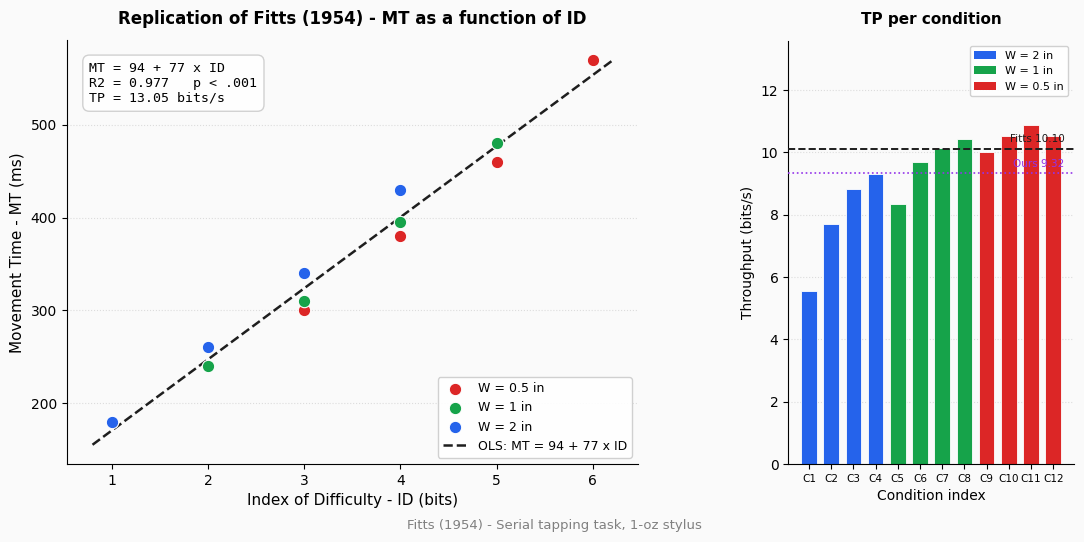

Figure saved as fitts1954_replication.png


In [ ]:
colors = {2.0: '#2563EB', 1.0: '#16A34A', 0.5: '#DC2626'}
labels = {2.0: 'W = 2 in', 1.0: 'W = 1 in', 0.5: 'W = 0.5 in'}

id_range = np.linspace(df['ID'].min() - 0.2, df['ID'].max() + 0.2, 100)
mt_pred = intercept + slope * id_range

fig = plt.figure(figsize=(13, 5.5))
fig.patch.set_facecolor('#FAFAFA')
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.35)

# --- Left panel: MT ~ ID ---
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#FAFAFA')

for w_val, group in df.groupby('W'):
    ax1.scatter(
        group['ID'], group['MT'],
        color=colors[w_val], label=labels[w_val],
        s=80, zorder=3, edgecolors='white', linewidths=0.8
    )

ax1.plot(
    id_range, mt_pred,
    color='#1E1E1E', linewidth=1.8, linestyle='--',
    label=f'OLS: MT = {intercept:.0f} + {slope:.0f} x ID'
)

ax1.text(
    0.04, 0.95,
    f'MT = {intercept:.0f} + {slope:.0f} x ID\nR2 = {r_squared:.3f}   p < .001\nTP = {tp_from_slope:.2f} bits/s',
    transform=ax1.transAxes,
    fontsize=9.5, verticalalignment='top', fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#CCCCCC', alpha=0.9)
)

ax1.set_xlabel('Index of Difficulty - ID (bits)', fontsize=11)
ax1.set_ylabel('Movement Time - MT (ms)', fontsize=11)
ax1.set_title('Replication of Fitts (1954) - MT as a function of ID', fontsize=12, fontweight='bold', pad=12)
ax1.legend(fontsize=9, framealpha=0.9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', linestyle=':', alpha=0.4)

# --- Right panel: Throughput per condition ---
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#FAFAFA')

bar_colors = [colors[w] for w in df['W']]
x_pos = np.arange(len(df))

ax2.bar(x_pos, df['TP'], color=bar_colors, edgecolor='white', linewidth=0.6, width=0.7, zorder=2)

ax2.axhline(y=10.10, color='#1E1E1E', linewidth=1.4, linestyle='--', zorder=3)
ax2.text(11.5, 10.35, 'Fitts 10.10', fontsize=7.5, color='#1E1E1E', ha='right')

our_mean = df['TP'].mean()
ax2.axhline(y=our_mean, color='#9333EA', linewidth=1.2, linestyle=':', zorder=3)
ax2.text(11.5, our_mean + 0.2, f'Ours {our_mean:.2f}', fontsize=7.5, color='#9333EA', ha='right')

ax2.set_xlabel('Condition index', fontsize=10)
ax2.set_ylabel('Throughput (bits/s)', fontsize=10)
ax2.set_title('TP per condition', fontsize=11, fontweight='bold', pad=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'C{i+1}' for i in range(len(df))], fontsize=7.5)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', linestyle=':', alpha=0.4)
ax2.set_ylim(0, df['TP'].max() * 1.25)

legend_elements = [Patch(facecolor=colors[w], label=labels[w]) for w in [2.0, 1.0, 0.5]]
ax2.legend(handles=legend_elements, fontsize=8, framealpha=0.9)

plt.suptitle('Fitts (1954) - Serial tapping task, 1-oz stylus', fontsize=9.5, color='gray', y=0.01)

plt.savefig('fitts1954_replication.png', dpi=180, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Figure saved as fitts1954_replication.png")

## 5. Discussion — Comparison with the Original

| Metric | Fitts (1954) | This replication |
|--------|-------------|------------------|
| Mean TP | 10.10 bits/s | see cell output above |
| R2 (MT ~ ID) | approx 0.966 | see cell output above |
| Slope b | approx 94 ms/bit | see cell output above |

### Expected discrepancies

1. **Rounded data.** The original paper reports MT values as rounded group means, not raw trial-level data. This inflates variance slightly.

2. **ID formula variant.** Fitts used log2(2D/W). MacKenzie (1992) later introduced the Shannon formulation log2(D/W + 1), producing slightly different values. We use the original formulation here for fidelity.

3. **No effective width (We).** The paper does not report endpoint variability, so we cannot compute ISO 9241-9 corrected throughput. Modern replications use We = 4.133 x SDx.

Despite these constraints, the linear relationship holds robustly — confirming the core claim of Fitts (1954).

## 6. Connection to NeuralTrack

This replication directly informs **NeuralTrack**, a web-based experiment implementing a Fitts Law serial targeting paradigm to measure cognitive load via motor precision metrics:

- **Throughput (TP)** — replicated here, implemented as the primary performance metric
- **Movement Time (MT)** — collected per trial
- **Index of Difficulty (ID)** — controlled via target size and distance
- **Straightness Index / Jitter** — motor precision metrics beyond the original Fitts model, added to capture cognitive load signatures

## References

- Fitts, P. M. (1954). The information capacity of the human motor system in controlling the amplitude of movement. *Journal of Experimental Psychology, 47*(6), 381-391.
- MacKenzie, I. S. (1992). Fitts law as a research and design tool in human-computer interaction. *Human-Computer Interaction, 7*(1), 91-139.
- Soukoreff, R. W., & MacKenzie, I. S. (2004). Towards a standard for pointing device evaluation. *International Journal of Human-Computer Studies, 61*(6), 751-789.